Test and debug functions from fmatoolbox

In [39]:
import fmatoolbox as fma
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'

In [14]:
# test loadSpikeTimes
spikes = fma.data.loadSpikeTimes(session)

In [16]:
# test loadEvents
events = fma.data.loadEvents(session,['sws','rem','InfraSlowRhythm/slownr','InfraSlowRhythm/slowavalnr'])

In [33]:
# test consolidateIntervals
intervals = [[1,3.2],[6,8],[2,4],[9,11],[10,11],[11.1,12.1],[11.6,11.8]]
fma.general.consolidateIntervals(intervals)

array([[ 1. ,  4. ],
       [ 6. ,  8. ],
       [ 9. , 11. ],
       [11.1, 12.1]])

In [34]:
# test intersectIntervals
intervals1 = [[2,12],[15,17.5]]
intervals2 = [[2,3],[5,7.5],[8.1,11]]
intervals3 = [[2,5],[5.5,5.8],[6,7],[8.5,11.5],[14,16]]
intervals4 = [[1,4],[5,5.5],[6,8],[11.1,16.5]]
fma.general.intersectIntervals((intervals1,intervals2,intervals3,intervals4))

array([[2., 3.],
       [6., 7.]])

In [3]:
# test subtractIntervals
intervals1 = [[1,3],[5.5,8],[11,11.5],[15,20]]
intervals2 = [[5,6],[7,7.5],[10,12],[14,15],[16,17],[19,21]]
fma.general.subtractIntervals(intervals1,intervals2)

array([[ 1. ,  3. ],
       [ 6. ,  7. ],
       [ 7.5,  8. ],
       [15. , 16. ],
       [17. , 19. ]])

In [32]:
# test restrict

# first column of samples is assumed to be time stamps at which all other columns are evaluated
samples = [[0,9],[1.1,5],[3,8],[4,-1.5],[9,9],[7,2],[12,-2]]
# every row of intervals is an interval, sample time stamps must fall in at least one interval
intervals = [[1,3.2],[6,8],[11,14]]
A, B, C = fma.general.restrict(samples,intervals,s_ind=True,i_ind=True)
A, B, C

(array([[ 1.1,  5. ],
        [ 3. ,  8. ],
        [ 7. ,  2. ],
        [12. , -2. ]]),
 array([False,  True,  True, False, False,  True,  True]),
 array([0, 0, 1, 2]))

In [ ]:
# test shuffleEvents
#fma.general.shuffleEvents([[1,4,1],[5,4,1],[6,8,0],[8,4,0],[10,8,0],[11,4,0],[12,4,1],[13,4,0],[14,8,0]])
fma.general.shuffleEvents([[1,4],[5,7],[6,8],[8,4],[10,8],[11,4],[12,4],[13,7],[14,8]],offset=0.5)

array([[ 1.5,  4. ],
       [ 2. ,  4. ],
       [ 4.5,  8. ],
       [ 5. ,  7. ],
       [ 8.5,  8. ],
       [ 9. ,  4. ],
       [12. ,  4. ],
       [13. ,  7. ],
       [14. ,  8. ]])

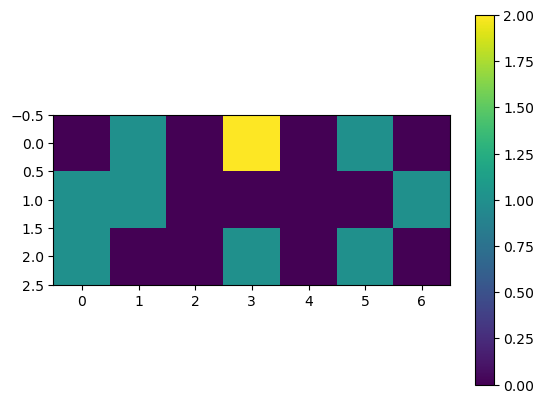

In [46]:
# test PETH
A, B, C = fma.analysis.PETH([1,3,4.1,4.2,5,7,8,11,13,15,16,18,20,24,25,26],[4,9,15],limits=[-2.1,2.1],n_bins=7)
plt.imshow(A)
plt.colorbar()